## Decision Tree
Decision Tree is supervised machine learning algorithm, which means it is able to predict a category for new unseen data that is also labelled with some class. It does this by repeatedly adding a yes/no question about one of the features to the splitting process (e.g., “Is attending_rate below 0.42?”), creating a tree of yes-no decisions until it is certain of the label.

The Decision Tree is used here to predict the higher or lower risk for illiteracy at the local level in Nepal, with regards to school attendance, literacy outcomes and educational attainment rates. This helps the Nepal Ministry of Education to understand exactly whether this community is at-risk or not, because all of the predictions can be easily traced back, in a line for a readable set of rules, and not through a black box.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

RANDOM_STATE = 42


## 1. Load Data and remove target variable
The preprocessed dataset is loaded and the target variable is extracted from the features creating a separate variable called 'high_illiteracy_risk'. The target is checked to confirm it's balanced (50% high-risk, 50% low-risk), which means plain accuracy is a fair metric to use later — but Precision, Recall, and F1 are still reported since missing a genuinely at-risk area matters more than a false alarm.

In [24]:
df = pd.read_csv('../data/processed_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (17824, 21)


,sex,agegrp,rowtotal_17,rowtotal_18,rowtotal_20,high_illiteracy_risk,early_edu_rate,primary_rate,secondary_rate,slc_rate,...,attending_rate,ever_attending_rate,never_attending_rate,prov_1,prov_2,prov_3,prov_4,prov_5,prov_6,prov_7
0,1,5,144,134,144,1,1.000000,0.000000,0.0,0.0,...,0.930556,0.000000,0.069444,True,False,False,False,False,False,False
1,1,6,132,129,132,1,0.147287,0.852713,0.0,0.0,...,0.977273,0.000000,0.022727,True,False,False,False,False,False,False
2,1,7,122,119,122,1,0.042017,0.957983,0.0,0.0,...,0.975410,0.000000,0.024590,True,False,False,False,False,False,False
3,1,8,113,107,113,1,0.028037,0.971963,0.0,0.0,...,0.946903,0.000000,0.053097,True,False,False,False,False,False,False
4,1,9,127,125,127,0,0.000000,1.000000,0.0,0.0,...,0.960630,0.023622,0.015748,True,False,False,False,False,False,False


In [25]:
X = df.drop(columns=['high_illiteracy_risk'])
y = df['high_illiteracy_risk']

y.value_counts(normalize=True)

high_illiteracy_risk
0    0.500224
1    0.499776
Name: proportion, dtype: float64

## 2. Train/Test Split
The data is originally divided into two portions: 80% for training the model and 20% is reserved for testing the model. This test set is used like "unseen" data — it tests the Decision Tree's performance on local levels not encountered at training time, on which it has not necessarily memorized the data.

By setting stratify=y, you ensure that the train set and the test set will provide the 50/50 ratio of high-risk vs low-risk local levels that is found when running on the entire data set, rather than mistakenly selecting mostly one class of the datasets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (14259, 20)  Test: (3565, 20)


## 3. Train a Baseline Decision Tree (all features)
A first Decision Tree is trained with all available features, up to a max depth of 6 to prevent it from getting too complex. In this case, the accuracy, precision, recall and f1-score are measured on the test set and the feature importances are examined to inspect which columns did the tree use more.

In [27]:
baseline = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6)
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred_base))
print("Precision:", precision_score(y_test, pred_base))
print("Recall   :", recall_score(y_test, pred_base))
print("F1-score :", f1_score(y_test, pred_base))

Accuracy : 0.9458625525946704
Precision: 0.9506522972206466
Recall   : 0.9405162738496072
F1-score : 0.9455571227080395


In [28]:
importances = pd.Series(baseline.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)


never_attending_rate    0.937053
early_edu_rate          0.039505
attending_rate          0.007319
ever_attending_rate     0.004348
agegrp                  0.002237
rowtotal_20             0.002085
primary_rate            0.001835
slc_rate                0.001370
prov_4                  0.001228
rowtotal_18             0.000930
dtype: float64

## 4. Investigate: Data Leakage Check
The model is nearly 94% accurate from just the `never_attending_rate` column, which is roughly the top 94% of the feature importance of the tree. This is a data leakage red flag: `never_attending_rate` is measuring almost the same thing as the target (`high_illiteracy_risk`) — a local level where nobody ever attended school is by definition going to be labelled high-illiteracy-risk, so the model isn't really learning a generalizable pattern, it's finding a near-duplicate of the label.

For an honest, generalizable model, this column is dropped before the "real" model is trained below.

## 5. Train the Corrected Decision Tree (leakage feature removed)
The leaking feature is removed, and the data is again split into two segments of training and test sets; this is to enable the data to be fairly used for the training and testing of a corrected model without the use of such a shortcut feature.

In [29]:
X_clean = X.drop(columns=['never_attending_rate'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


### 5.1 Hyperparameter Tuning (max_depth, min_samples_leaf)
GridSearchCV uses 5-fold cross-validation to test a variety of possible combinations of max_depth and min_samples_leaf values, and selects the configuration that produces the highest F1 score. This will prevent underfitting (too shallow a tree) and will prevent overfitting (too deep a tree, memorizing noise).

In [30]:
param_grid = {'max_depth': [3, 4, 5, 6, 8, 10, 12, None],
              'min_samples_leaf': [1, 5, 10]}

grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                     param_grid, cv=5, scoring='f1')
grid.fit(X_train_c, y_train_c)

print("Best params:", grid.best_params_)
print("Best CV F1 :", grid.best_score_)


Best params: {'max_depth': None, 'min_samples_leaf': 10}
Best CV F1 : 0.9279622603918944


### 5.2 Final Model
All the above mentioned hyperparameters are then optimized to train the final Decision Tree and performance is plotted on the test set using accuracy, precision, recall and f1 score.

In [31]:
final_model = grid.best_estimator_
pred = final_model.predict(X_test_c)

acc = accuracy_score(y_test_c, pred)
prec = precision_score(y_test_c, pred)
rec = recall_score(y_test_c, pred)
f1 = f1_score(y_test_c, pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print()
print(classification_report(y_test_c, pred))

Accuracy : 0.9175
Precision: 0.9237
Recall   : 0.9102
F1-score : 0.9169

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1783
           1       0.92      0.91      0.92      1782

    accuracy                           0.92      3565
   macro avg       0.92      0.92      0.92      3565
weighted avg       0.92      0.92      0.92      3565



## 6. Confusion Matrix
The confusion matrix reports on the exact number of correct and incorrect local levels (TP, TN, FP, FN) along with accuracy, which gives a better picture than just the accuracy.

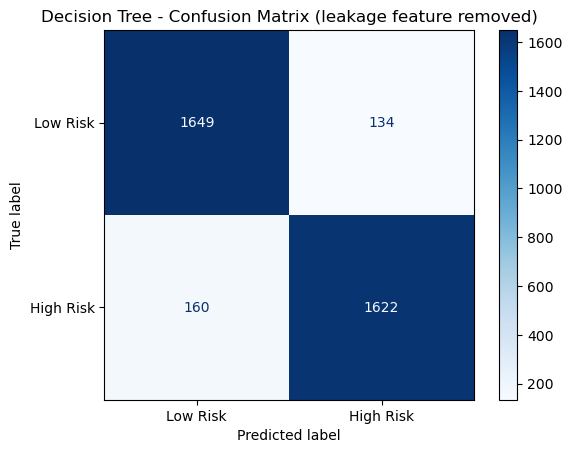

In [32]:
cm = confusion_matrix(y_test_c, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Blues')
plt.title('Decision Tree - Confusion Matrix (leakage feature removed)')
plt.show()

 ## 7. Feature importance (final model)

This shows which features the corrected Decision Tree actually relies on most, now that the leaking column has been removed.

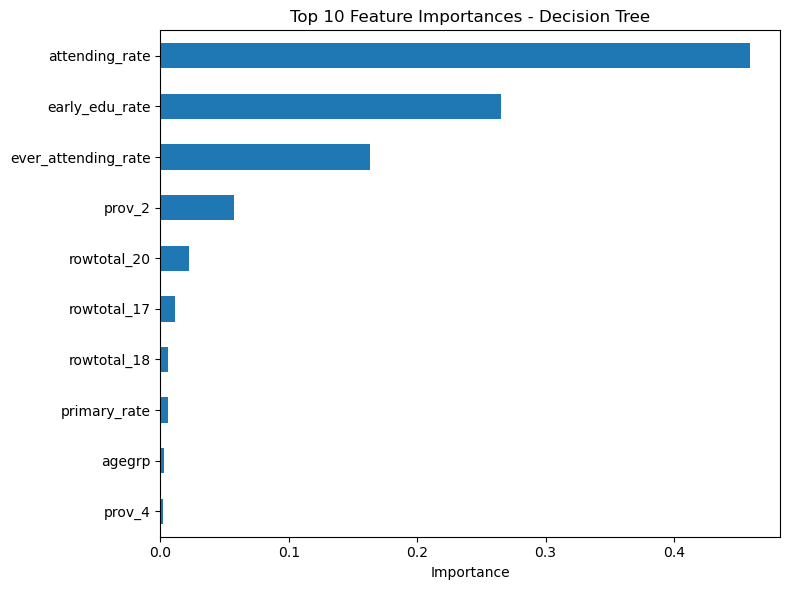

attending_rate         0.459615
early_edu_rate         0.265050
ever_attending_rate    0.162923
prov_2                 0.057267
rowtotal_20            0.022538
rowtotal_17            0.011392
rowtotal_18            0.006317
primary_rate           0.006015
agegrp                 0.003075
prov_4                 0.002261
dtype: float64

In [33]:
final_importances = pd.Series(final_model.feature_importances_, index=X_clean.columns)\
    .sort_values(ascending=False)

plt.figure(figsize=(8,6))
final_importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

final_importances.head(10)

## 8. Visualize the Tree (top levels)
The top 3 levels of the tree are visualized to show exactly which questions the model asks first, and how it splits local levels into high-risk vs low-risk groups.

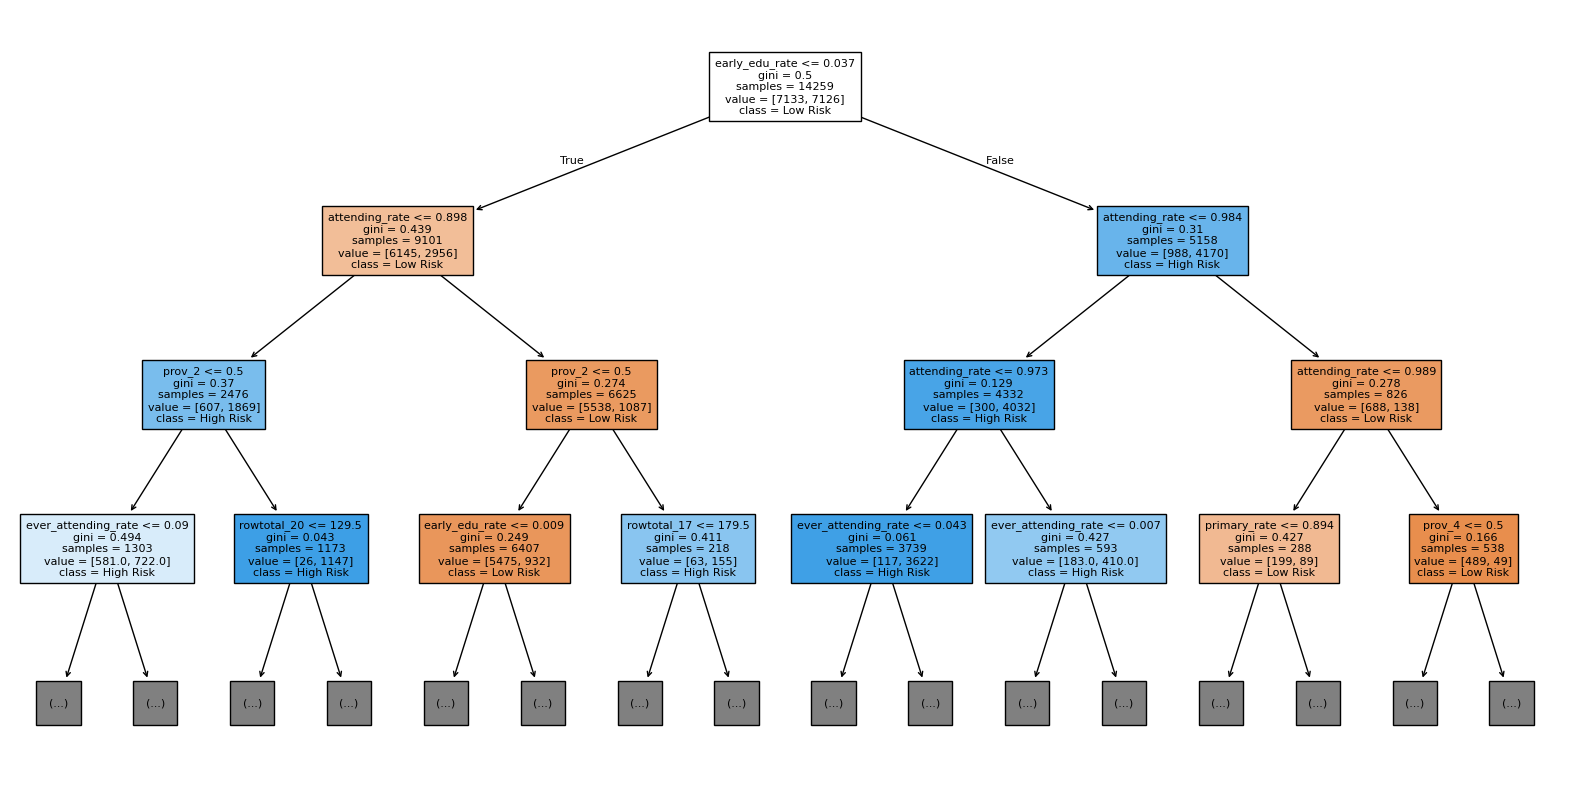

In [34]:
plt.figure(figsize=(20,10))
plot_tree(final_model, max_depth=3, feature_names=X_clean.columns,
          class_names=['Low Risk','High Risk'], filled=True, fontsize=8)
plt.show()

## 9. Summary of Findings

- A baseline model with all features achieved a test accuracy of ~94%, but this was almost entirely dependent on `never_attending_rate`, which was a data leakage issue because this feature essentially contains the target variable already.
- After removing `never_attending_rate` and tuning `max_depth` / `min_samples_leaf` via GridSearchCV, the corrected Decision Tree achieves a more trustworthy and still strong performance, driven by a more balanced mix of features such as `attending_rate`, `early_edu_rate`, and `ever_attending_rate`.